In [11]:
import pandas as pd
import numpy as np

In [12]:
human = pd.read_csv("../data/human_annotations.csv")
# missing values?
print(f"Missing values in human annotations: {human.isnull().sum().sum()}")
# shape
print(f"Shape of human annotations: {human.shape}")
# unique item_id
print(f"Unique item IDs in human annotations: {human['item_id'].nunique()}")

# rname columns for clarity
human.columns = ["item_id"] + [f"human_#{i}" for i in range(1, human.shape[1])]
human.head()

Missing values in human annotations: 566
Shape of human annotations: (228, 9)
Unique item IDs in human annotations: 228


,item_id,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8
0,1,5.0,4.0,NaN,3.0,5.0,NaN,5.0,4.0
1,4,3.0,NaN,5.0,5.0,3.0,4.0,5.0,3.0
2,7,4.0,2.0,5.0,2.0,NaN,2.0,5.0,NaN
3,8,1.0,4.0,5.0,4.0,5.0,NaN,5.0,3.0
4,9,5.0,4.0,5.0,3.0,5.0,NaN,5.0,4.0


In [13]:
llm = pd.read_csv("../data/llm_ratings_gpt-4o-mini.csv")
# missing values?
print(f"Missing values in LLM ratings: {llm.isnull().sum().sum()}")
# shape
print(f"Shape of LLM ratings: {llm.shape}")

# # unique item_id
print(f"Unique item IDs in LLM ratings: {llm['item_id'].nunique()}")

llm.columns  = ["item_id", "gpt-4o-mini"]

llm.head()

Missing values in LLM ratings: 10
Shape of LLM ratings: (1682, 2)
Unique item IDs in LLM ratings: 1682


,item_id,gpt-4o-mini
0,1,5.0
1,2,4.0
2,3,3.0
3,4,4.0
4,5,3.0


In [14]:
merged = pd.merge(human, llm, on="item_id", suffixes=("_human", "_llm"))
print(f"Merged dataset shape: {merged.shape}")


# filter where nan
merged.dropna(inplace=True)


print(f"Merged dataset shape after dropping NaNs: {merged.shape}")
merged.head()

Merged dataset shape: (228, 10)
Merged dataset shape after dropping NaNs: (17, 10)


,item_id,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,gpt-4o-mini
6,12,5.0,4.0,5.0,5.0,5.0,3.0,5.0,4.0,5.0
12,22,4.0,3.0,5.0,4.0,5.0,3.0,5.0,4.0,5.0
34,70,3.0,3.0,1.0,3.0,4.0,4.0,4.0,4.0,4.0
48,98,4.0,5.0,4.0,4.0,5.0,3.0,5.0,4.0,5.0
50,100,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0


#### Find combination of of at least 3 humans that provide most data points

In [15]:
import itertools
import pandas as pd

# Identify human and LLM columns
human_cols = [c for c in merged.columns if c.startswith("human_")]
llm_col = "gpt-4o-mini"

results = []

# Loop through all combinations of ≥3 humans
for k in range(3, len(human_cols) + 1):
    for combo in itertools.combinations(human_cols, k):
        subset_cols = list(combo) + [llm_col]
        # Drop only NaNs in this subset
        n_valid = merged.dropna(subset=subset_cols).shape[0]
        results.append({
            "num_humans": k,
            "combination": combo,
            "n_items": n_valid
        })

# Convert to DataFrame and sort by n_items
results_df = pd.DataFrame(results).sort_values("n_items", ascending=False)

# Display top results
print("🔝 Top combinations (≥3 humans) with most complete rows:")
#shape
print(f"Results DataFrame shape: {results_df.shape}")

results_df.head(10)

🔝 Top combinations (≥3 humans) with most complete rows:
Results DataFrame shape: (219, 3)


,num_humans,combination,n_items
0,3,"(human_#1, human_#2, human_#3)",17
150,5,"(human_#1, human_#3, human_#4, human_#6, human...",17
139,5,"(human_#1, human_#2, human_#4, human_#6, human...",17
140,5,"(human_#1, human_#2, human_#4, human_#6, human...",17
141,5,"(human_#1, human_#2, human_#4, human_#7, human...",17
142,5,"(human_#1, human_#2, human_#5, human_#6, human...",17
143,5,"(human_#1, human_#2, human_#5, human_#6, human...",17
144,5,"(human_#1, human_#2, human_#5, human_#7, human...",17
145,5,"(human_#1, human_#2, human_#6, human_#7, human...",17
146,5,"(human_#1, human_#3, human_#4, human_#5, human...",17


### Analysis

In [16]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

✅ Found 8 valid human annotator columns.
✅ Keeping 17/17 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'
📊 Computing disagreement distributions...


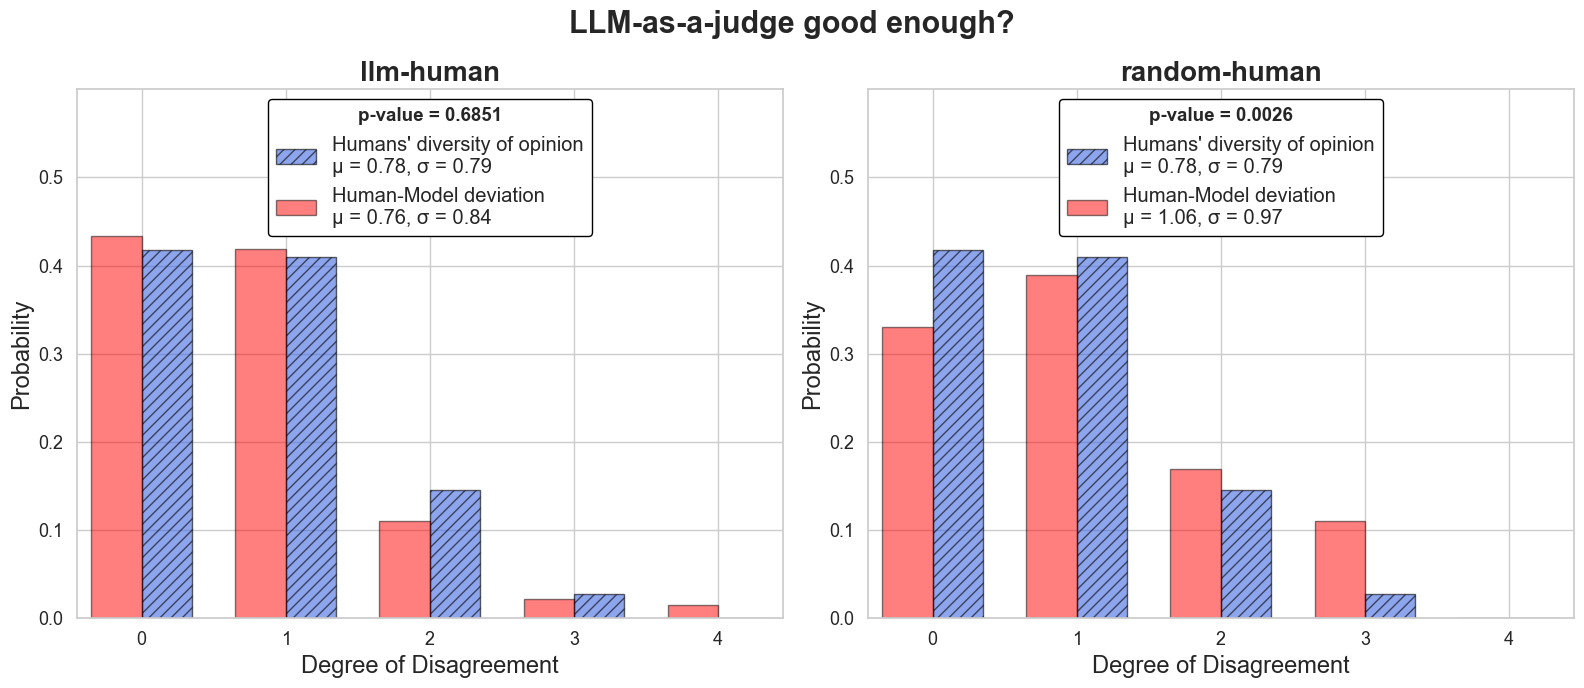

In [17]:
MIN, MAX = 1, 5
HUMAN_COLS = [c for c in merged.columns if c.startswith("human_")]

judge = LLMGoodEnough(
    df=merged,
    human_cols=HUMAN_COLS,
    min_score=MIN, max_score=MAX
)

judge.visualize_good_enough(llm_col="gpt-4o-mini", y_lim=0.6)

In [18]:
human_human_disagreements = judge.compute_human_disagreements()

print(human_human_disagreements.shape)
# mean and std (=2 decimal places)
print(f"Mean: {round(human_human_disagreements.mean(), 2)}")
print(f"Std: {round(human_human_disagreements.std(), 2)}")

(476,)
Mean: 0.78
Std: 0.79


Merged dataset shape: (228, 10)
✅ Found 8 valid human annotator columns.
✅ Keeping 228/228 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'
📊 Computing disagreement distributions...


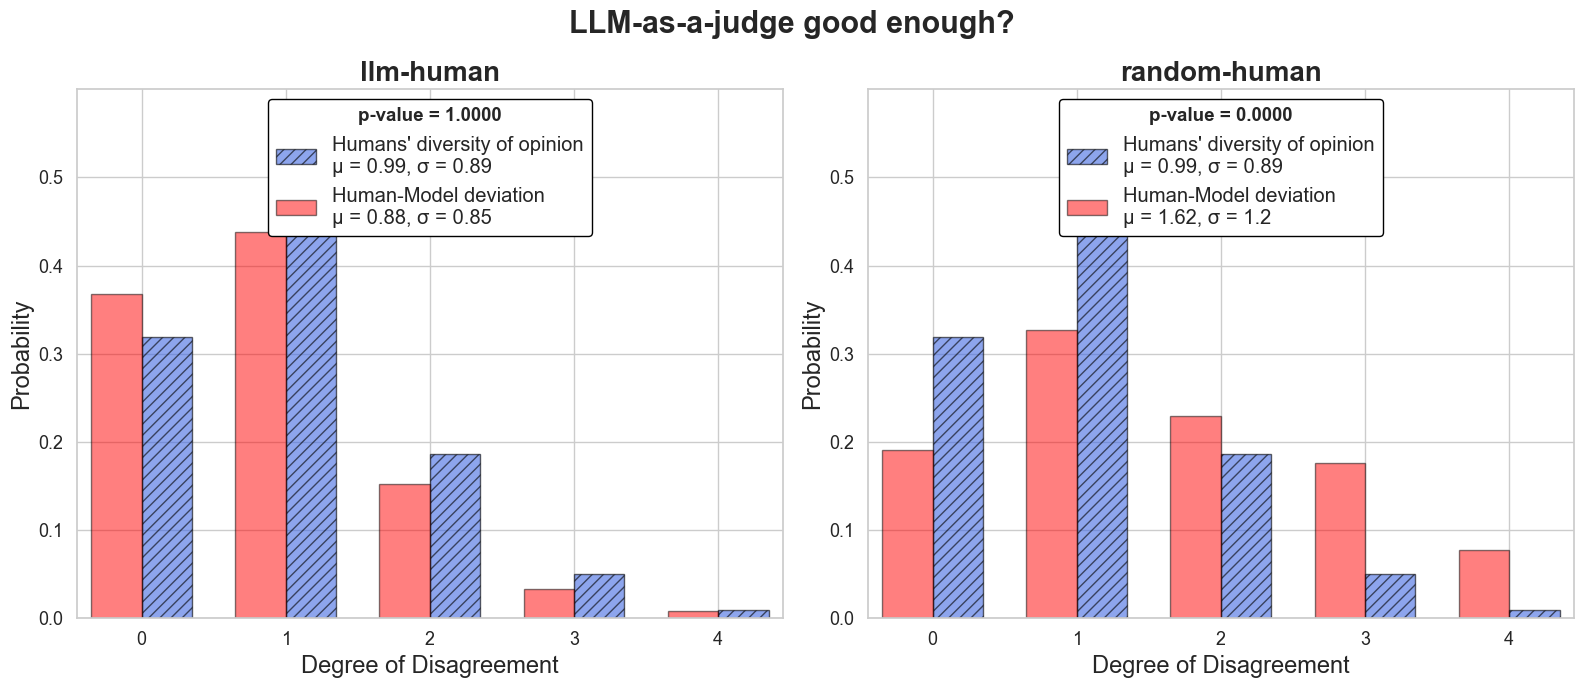

In [19]:
merged = pd.merge(human, llm, on="item_id", suffixes=("_human", "_llm"))
print(f"Merged dataset shape: {merged.shape}")


judge = LLMGoodEnough(
    df=merged,
    human_cols=HUMAN_COLS,
    min_score=1, max_score=5
)

judge.visualize_good_enough(llm_col="gpt-4o-mini", y_lim=0.6)